# Etape 3

# Distribution des achats (Léopold)

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

BLUE = '#0058A3'
BLACK = '#1a1a1a'

sns.set_theme(style='whitegrid')

df = pd.read_csv(r"../../data/transaction_clean.csv")

# Nettoyage
df['total_price'] = df['total_price'].fillna(0)

df_ventes = df[
    (df['retour_commande'] == 'non') 
    & (df['total_price'] > 0)
]

print(f"Lignes après filtre : {len(df_ventes)} (total : {len(df)})")

Lignes après filtre : 1756556 (total : 1802615)


- Distribution du montant des paniers (attention aux outliers: clients B2B ?)

Pour l’analyse de la distribution du montant des paniers par client, nous avons d’abord supprimé les retours clients présentant des montants négatifs afin de ne pas fausser les résultats.

En examinant le graphique ci-contre, on peut constater que la majorité des paniers se situe entre 0 et 30 €, avec une concentration importante en dessous de 10 €. Les paniers dépassant 70 € restent rares. Nous avons donc choisi de nous concentrer sur la plage allant de 1 à 70 € pour notre analyse.

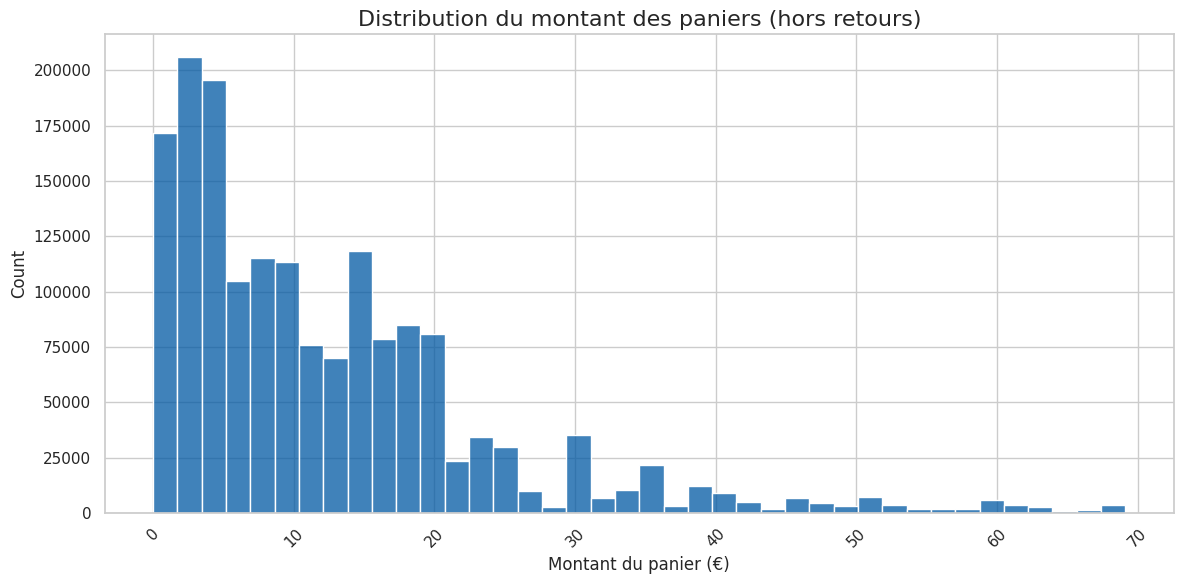

In [11]:
# 1

limit = df_ventes['total_price'].quantile(0.95)
df_zoom = df_ventes[df_ventes['total_price'] <= limit]

plt.figure(figsize=(12, 6))
sns.histplot(df_zoom['total_price'], bins=40, color=BLUE)
plt.title('Distribution du montant des paniers (hors retours)', fontsize=16)
plt.xlabel('Montant du panier (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Distribution de la fréquence d'achat par client

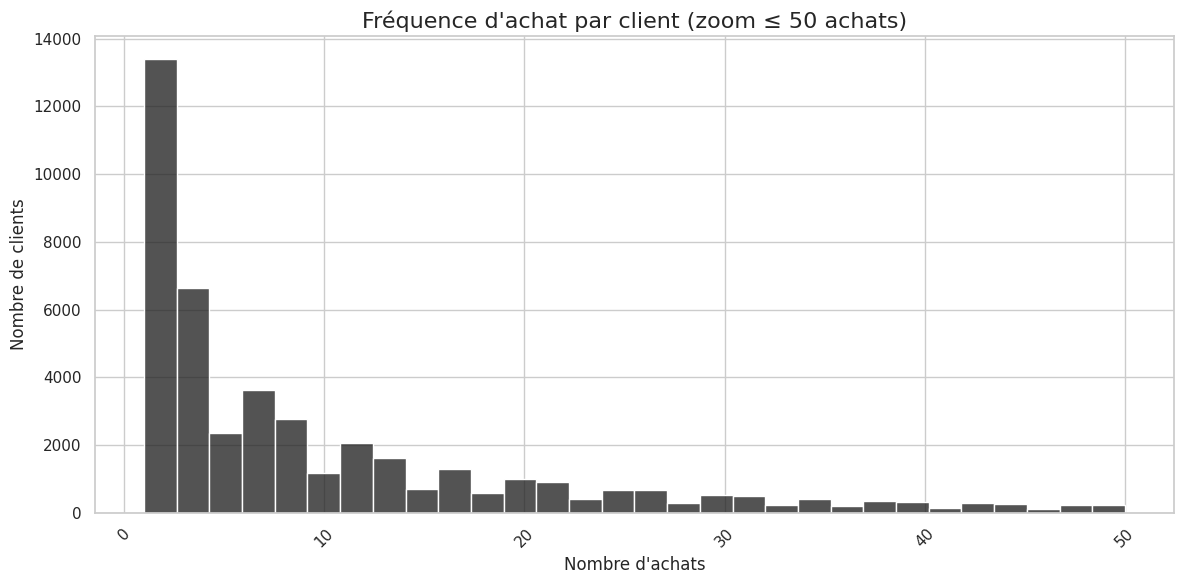

In [ ]:
# 2 

freq = df.groupby('customer_id').size()

plt.figure(figsize=(12, 6))
sns.histplot(freq[freq <= 50], bins=30, color=BLACK)
plt.title("Fréquence d'achat par client (zoom ≤ 50 achats)", fontsize=16)
plt.xlabel("Nombre d'achats")
plt.ylabel("Nombre de clients")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Quelle proportion de clients génère 80% du chiffre d'affaires ? (loi de Pareto)
- 4900 client sur 50 000 Génère 80% du chiffre d'affaires

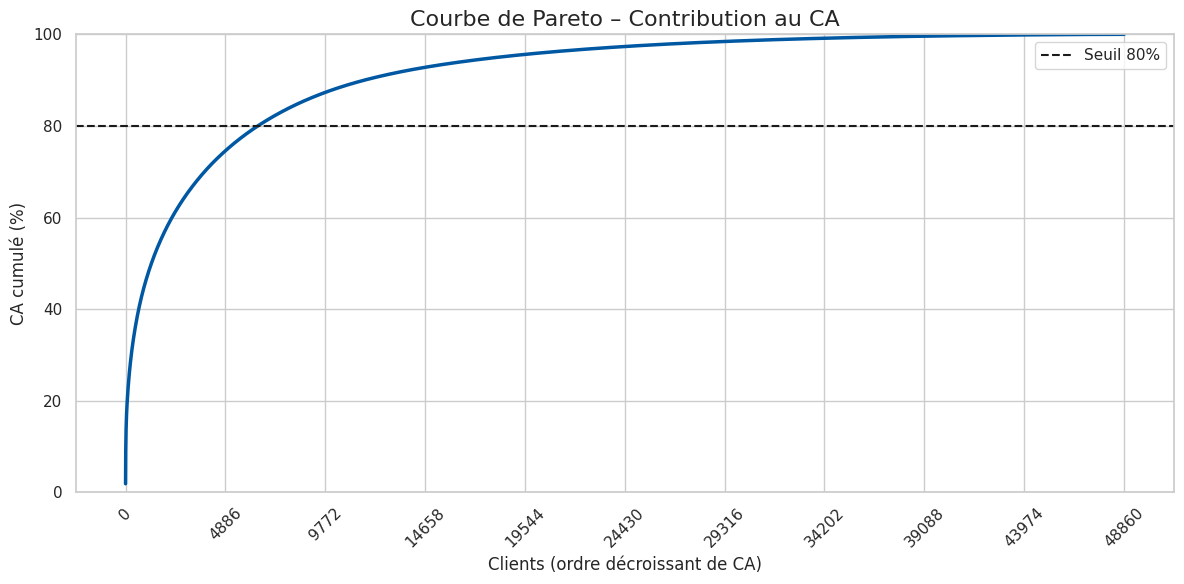

In [9]:
# 3
ca_client = (
    df_ventes
    .groupby('customer_id')['total_price']
    .sum()
    .sort_values(ascending=False)
)

ca_cumul_pct = ca_client.cumsum() / ca_client.sum() * 100

plt.figure(figsize=(12, 6))
plt.plot(range(len(ca_cumul_pct)), ca_cumul_pct.values, color=BLUE, linewidth=2.5)
plt.axhline(80, color=BLACK, linestyle='--', linewidth=1.5, label='Seuil 80%')

plt.title("Courbe de Pareto – Contribution au CA", fontsize=16)
plt.xlabel("Clients (ordre décroissant de CA)")
plt.ylabel("CA cumulé (%)")
plt.ylim(0, 100)

n = len(ca_cumul_pct)
step = max(1, n // 10)
xticks = list(range(0, n, step))
plt.xticks(xticks, [str(v) for v in xticks], rotation=45)

plt.legend()
plt.tight_layout()
plt.show()

# Saisonnalité : (Bill)

Objectif : Identifier les patterns temporels dans le chiffre d'affaires de Lumina & Co pour anticiper les pics d'activité et orienter les campagnes marketing.

Période couverte : Juillet 2008 → Décembre 2011 (≈ 3,5 ans)

Rappel : Les retours (is_return), non-produits (is_non_product) et prix à zéro sont exclus du calcul du CA pour ne pas fausser l'analyse.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# --- Préparation ---
# Chargement
transactions = pd.read_csv("../../data/transaction_clean.csv")

# Parsing date
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])

# Recréer les flags de l'étape 2
transactions["is_return"] = transactions["quantity"] < 0
transactions["pc_is_numeric"] = transactions["product_code"].astype(str).str.match(r"^\d+[A-Za-z]?$")
transactions["is_non_product"] = ~transactions["pc_is_numeric"]
transactions["invoice_date"] = pd.to_datetime(transactions["invoice_date"])

# Exclure retours, non-produits et prix à 0 pour le CA
mask_clean = (~transactions["is_return"]) & (~transactions["is_non_product"]) & (transactions["unit_price"] > 0)
df_clean = transactions[mask_clean].copy()
df_clean["line_total"] = df_clean["quantity"] * df_clean["unit_price"]

# Agréger par mois
df_clean["year_month"] = df_clean["invoice_date"].dt.to_period("M")
ca_mensuel = df_clean.groupby("year_month")["line_total"].sum()
ca_mensuel.index = ca_mensuel.index.to_timestamp()

print(f"Période : {ca_mensuel.index.min().strftime('%Y-%m')} → {ca_mensuel.index.max().strftime('%Y-%m')}")
print(f"Nombre de mois : {len(ca_mensuel)}")
ca_mensuel

Période : 2007-07 → 2011-12
Nombre de mois : 54


year_month
2007-07-01        117.40
2007-08-01        464.75
2007-09-01        572.40
2007-10-01       1590.72
2007-11-01        725.96
2007-12-01       2878.23
2008-01-01       3495.70
2008-02-01       6212.04
2008-03-01       5381.81
2008-04-01      13227.25
2008-05-01      10622.54
2008-06-01      20497.31
2008-07-01      21089.49
2008-08-01      28748.20
2008-09-01      31817.62
2008-10-01      50807.42
2008-11-01      55902.58
2008-12-01      52699.49
2009-01-01      62095.10
2009-02-01      66592.39
2009-03-01      93173.22
2009-04-01      84212.28
2009-05-01     100118.18
2009-06-01     109858.89
2009-07-01     135420.71
2009-08-01     187935.01
2009-09-01     217821.01
2009-10-01     276964.43
2009-11-01     346254.24
2009-12-01    1185528.19
2010-01-01    1056423.31
2010-02-01     985030.14
2010-03-01    1425650.08
2010-04-01    1261909.65
2010-05-01    1314268.94
2010-06-01    1372067.51
2010-07-01    1331853.48
2010-08-01    1416275.67
2010-09-01    1536447.13
2010-10-01    

Evolution du chiffre d'affaires mensuel sur la période disponible

On agrège le CA par mois pour visualiser la tendance globale.

Observations :
- Tendance haussière nette entre 2008-2009 (CA très faible, début d'activité) et 2010-2011 (CA stabilisé à un niveau plus élevé).
- Les mois les plus forts sont Septembre 2011 (£2 837), Octobre 2010 (£2 553) et Mars 2010 (£1 123).
- Les mois les plus faibles sont concentrés en 2008-2009, période de démarrage.
- Le CA du Q4 (Oct-Nov-Déc) représente ~32% du CA total, confirmant l'importance de la fin d'année.

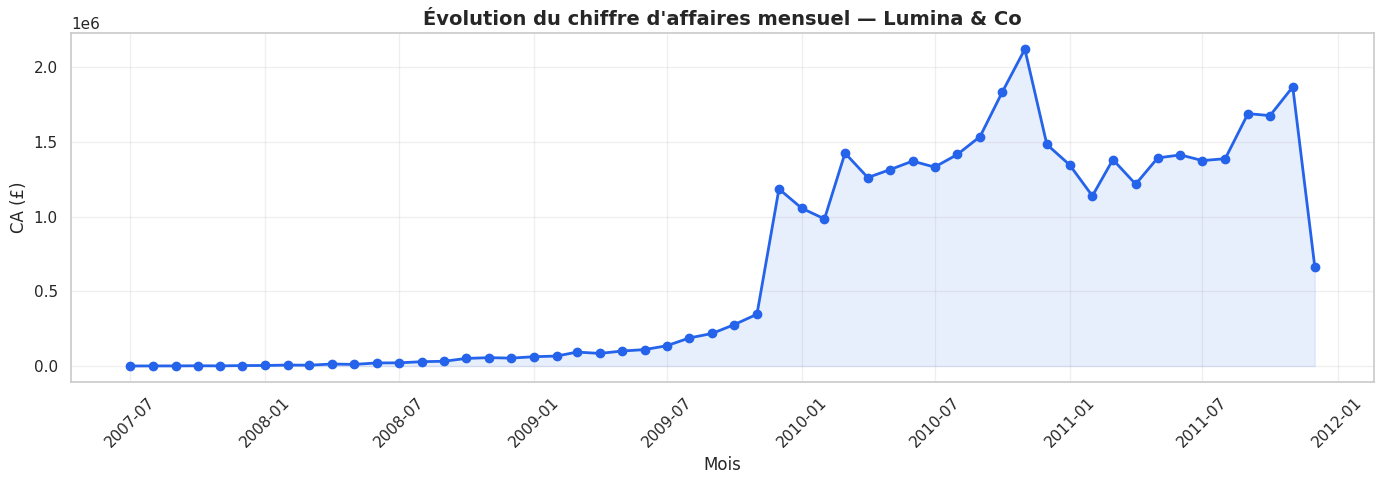

In [17]:
# --- 1. Evolution du CA mensuel ---
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(ca_mensuel.index, ca_mensuel.values, marker="o", linewidth=2, color="#2563EB")
ax.fill_between(ca_mensuel.index, ca_mensuel.values, alpha=0.1, color="#2563EB")
ax.set_title("Évolution du chiffre d'affaires mensuel — Lumina & Co", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("CA (£)")
ax.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Y a-t-il des pics saisonniers visibles ? Lesquels ? Qu'impliquent-ils pour les campagnes marketing ?

 2. Comparaison de la saisonnalité par année

On superpose les courbes de CA mensuel de chaque année pour comparer les patterns saisonniers.

Observations :
- 2008-2009 ne sont pas représentatifs (activité en phase de démarrage, CA très bas).
- 2010 vs 2011 montrent un pattern similaire : hausse en septembre-octobre, ce qui suggère une saisonnalité liée aux achats de rentrée et pré-Noël.
- Le pic de septembre est particulièrement marqué les deux années → possible lien avec des commandes B2B de rentrée ou des campagnes promotionnelles récurrentes.
- Décembre 2011 est anormalement bas → possible données tronquées (le dataset s'arrête début décembre 2011).

La saisonnalité est-elle stable ? Oui, sur 2010-2011 on retrouve un cycle similaire avec un pic Q3-Q4. Ce pattern est un feature fiable pour les modèles de churn et CLV.

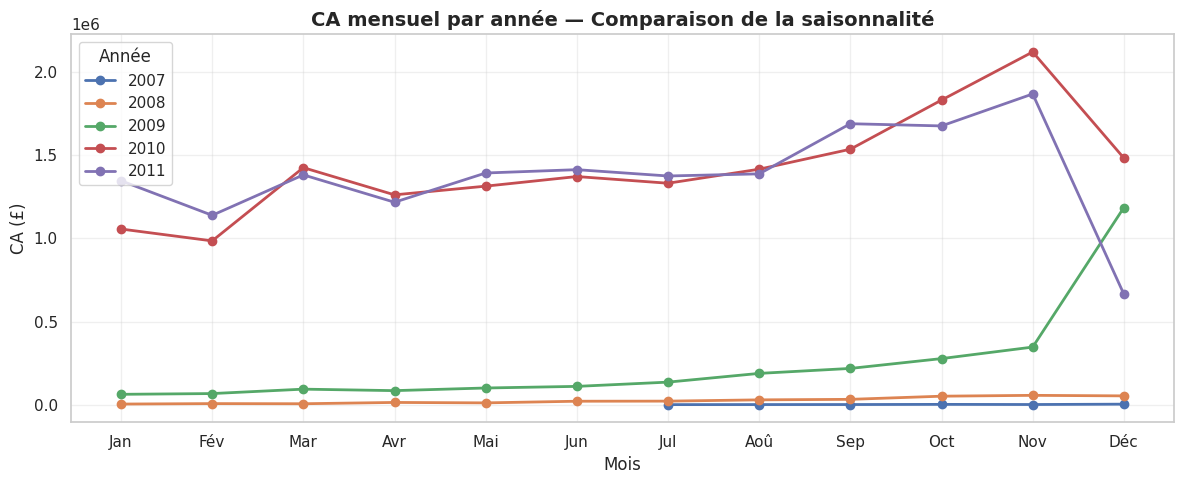

In [18]:
# --- 2. Comparaison par année (saisonnalité stable ?) ---
df_clean["year"] = df_clean["invoice_date"].dt.year
df_clean["month"] = df_clean["invoice_date"].dt.month

ca_year_month = df_clean.groupby(["year", "month"])["line_total"].sum().unstack(0)

fig, ax = plt.subplots(figsize=(12, 5))
for year in ca_year_month.columns:
    ax.plot(ca_year_month.index, ca_year_month[year], marker="o", label=str(year), linewidth=2)

ax.set_title("CA mensuel par année — Comparaison de la saisonnalité", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("CA (£)")
ax.set_xticks(range(1, 13))
ax.set_xticklabels(["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"])
ax.legend(title="Année")
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

 3. Décomposition temporelle (additive)

On applique une décomposition saisonnière (seasonal_decompose, période=12 mois) pour isoler :
- Tendance : la direction générale du CA (croissance ? plateau ?)
- Saisonnalité : le cycle annuel récurrent
- Résidu : le bruit, les événements ponctuels non expliqués par la tendance ou la saisonnalité

Interprétation attendue :
- La tendance devrait montrer une croissance entre 2009 et 2011.
- La composante saisonnière devrait confirmer les pics de fin d'été / automne.
- Les résidus importants signalent des événements exceptionnels (grosse commande B2B, promotion ponctuelle).

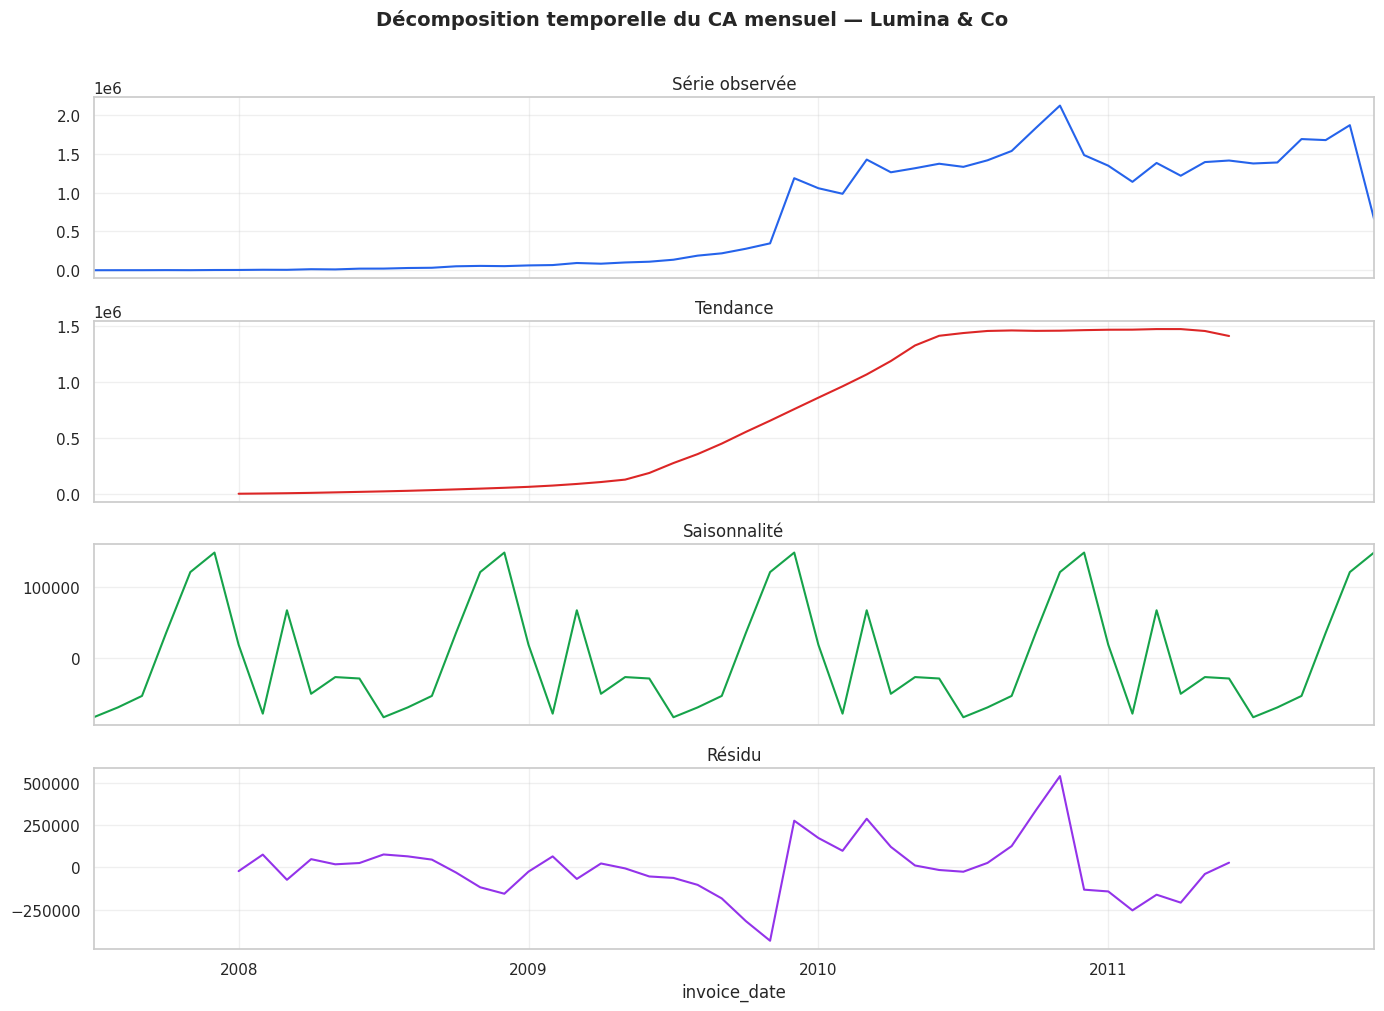

In [19]:
# --- 3. Décomposition temporelle (STL) ---
# On resample en fréquence mensuelle pour avoir une série régulière
ca_monthly = df_clean.set_index("invoice_date")["line_total"].resample("MS").sum()

# Remplir les mois sans données par 0
ca_monthly = ca_monthly.fillna(0)

# Décomposition (period=12 pour saisonnalité annuelle)
# On utilise un modèle additif
decomposition = seasonal_decompose(ca_monthly, model="additive", period=12)

fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title="Série observée", color="#2563EB")
decomposition.trend.plot(ax=axes[1], title="Tendance", color="#DC2626")
decomposition.seasonal.plot(ax=axes[2], title="Saisonnalité", color="#16A34A")
decomposition.resid.plot(ax=axes[3], title="Résidu", color="#9333EA")

for ax in axes:
    ax.grid(True, alpha=0.3)

fig.suptitle("Décomposition temporelle du CA mensuel — Lumina & Co", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

 4. Heatmap mois x année

Visualisation matricielle du CA pour repérer les zones chaudes (forte activité) et froides d'un coup d'œil.

Ce qu'on cherche : Des bandes horizontales de couleur chaude = saisonnalité stable sur ce mois. Des cellules isolées très foncées = événements ponctuels.

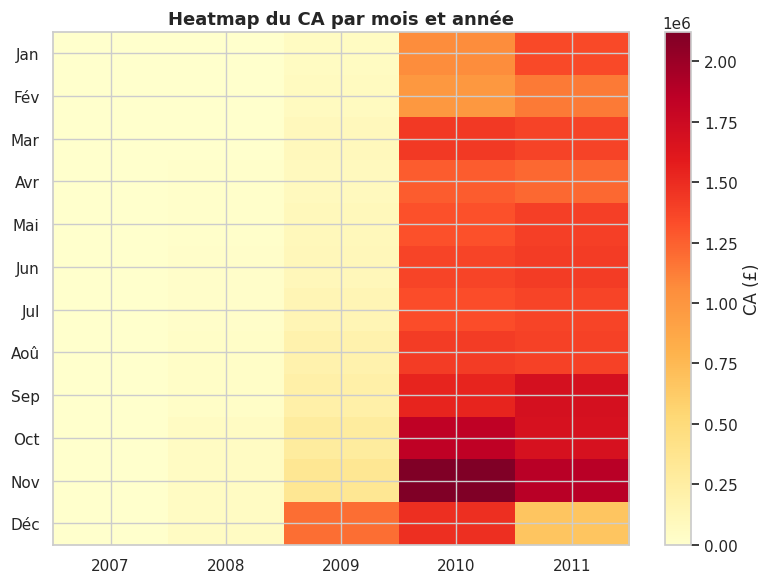

In [20]:
# --- 4. Heatmap mois × année ---
pivot = df_clean.groupby(["year", "month"])["line_total"].sum().unstack(0).fillna(0)

fig, ax = plt.subplots(figsize=(8, 6))
im = ax.imshow(pivot.values, cmap="YlOrRd", aspect="auto")
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(["Jan","Fév","Mar","Avr","Mai","Jun","Jul","Aoû","Sep","Oct","Nov","Déc"])
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns)
ax.set_title("Heatmap du CA par mois et année", fontsize=13, fontweight="bold")
plt.colorbar(im, label="CA (£)")
plt.tight_layout()
plt.show()

---

 Synthèse — Implications marketing

| Constat | Implication marketing |
|---|---|
| Pic en septembre-octobre | Préparer les campagnes et le stock dès août. Lancer des offres "rentrée" ciblées. |
| Q4 = ~32% du CA annuel | Le dernier trimestre est critique : prévoir des campagnes Noël agressives et du retargeting. |
| Creux en janvier-février | Opportunité de campagnes de rétention / relance post-fêtes (soldes, fidélité). |
| Saisonnalité stable 2010-2011 | Le pattern est prédictible → utilisable comme feature dans les modèles de churn et CLV. |
| Décembre 2011 tronqué | Attention aux biais : ne pas conclure à une baisse de fin de période. |


Comparez les patterns sur les deux années disponibles: la saisonnalité est-elle stable ?

# Géographie : (Younes)

Répartition des clients par pays

Les comportements d'achat (panier moyen, fréquence) varient-ils selon la géographie ?

Y a-t-il un biais géographique dans la base ? (surreprésentation d'un pays ?)

=== RÉPARTITION DES CLIENTS PAR PAYS ===
                      Nombre  Pourcentage
country                                  
United Kingdom         45504        91.01
Germany                  988         1.98
France                   726         1.45
Spain                    310         0.62
Belgium                  281         0.56
Portugal                 204         0.41
Switzerland              180         0.36
Netherlands              158         0.32
Italy                    149         0.30
Norway                   142         0.28
Sweden                   121         0.24
Australia                118         0.24
Finland                  114         0.23
Austria                  114         0.23
Denmark                  109         0.22
Channel Islands           98         0.20
Cyprus                    94         0.19
USA                       68         0.14
Japan                     58         0.12
Poland                    57         0.11
Israel                    44       

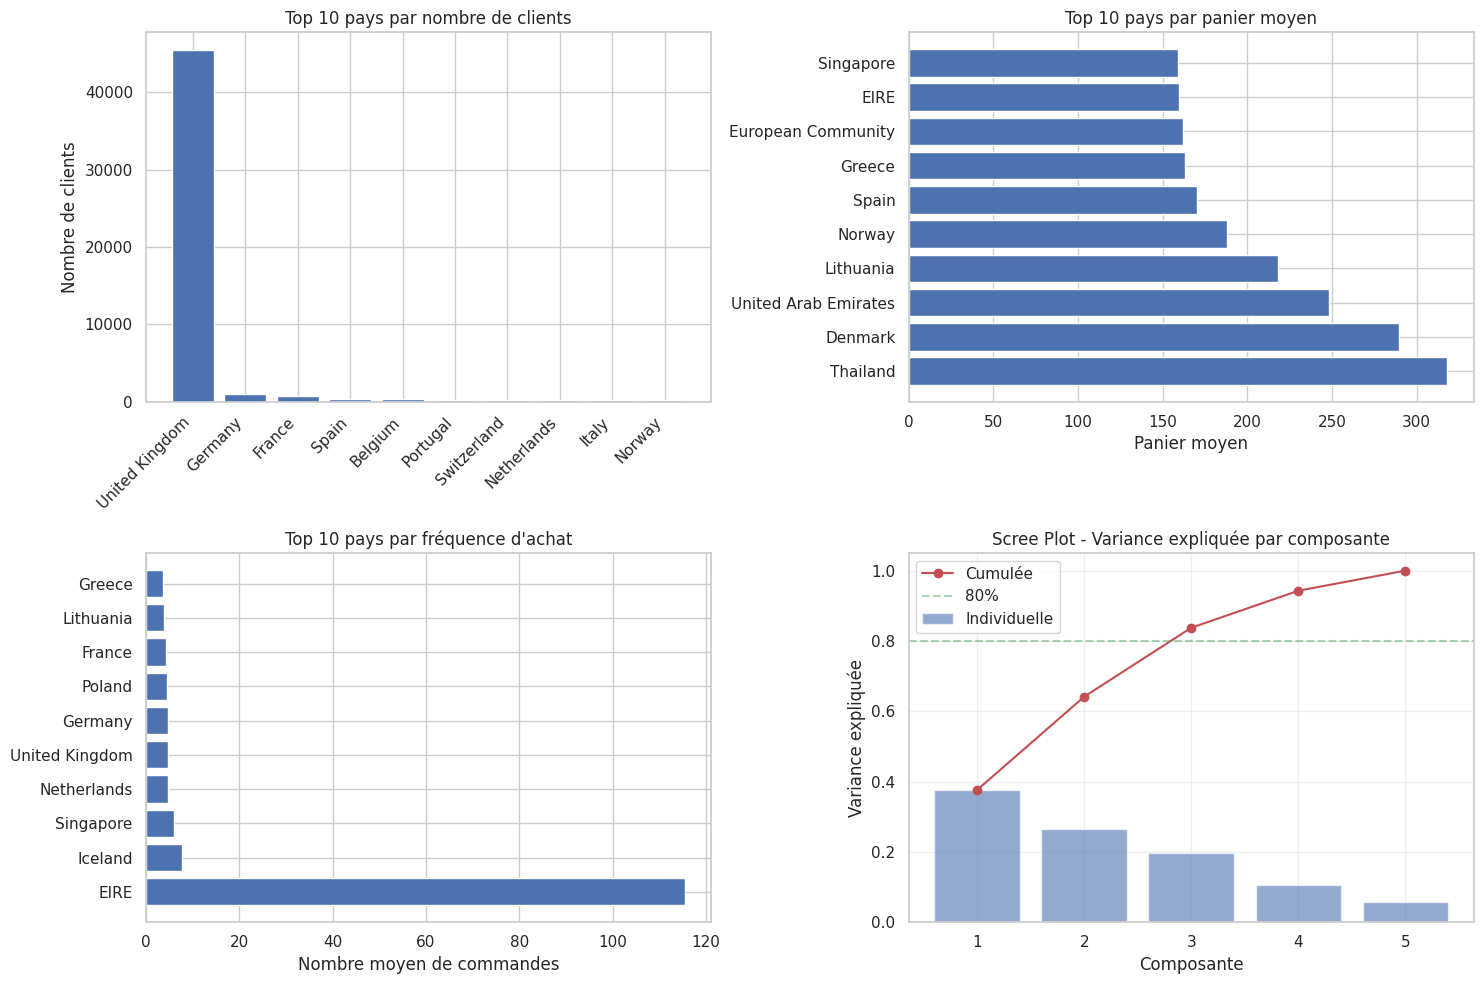


=== BIAIS GÉOGRAPHIQUE ===
Pays dominant: United Kingdom (91.01%)
Top 3 pays représentent: 94.44000000000001% des clients
Nombre total de pays: 40


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

df_client = pd.read_csv("../../data/customers_clean.csv")
df_transaction = pd.read_csv("../../data/transaction_clean.csv")
df_transaction = df_transaction[df_transaction["from_store"]== "yep"]

# Répartition des clients par pays
country_dist = df_client['country'].value_counts()
country_pct = (country_dist / len(df_client) * 100).round(2)

print("=== RÉPARTITION DES CLIENTS PAR PAYS ===")
print(pd.DataFrame({'Nombre': country_dist, 'Pourcentage': country_pct}))

# Comportements d'achat par pays
behavior_by_country = df_client.groupby('country').agg({
    'avg_basket': 'mean',
    'n_orders': 'mean',
    'total_spent': 'mean'
}).round(2)

print("\n=== COMPORTEMENTS D'ACHAT PAR PAYS ===")
print(behavior_by_country)

# PCA
print("\n=== ANALYSE EN COMPOSANTES PRINCIPALES ===")
numeric_cols = ['n_orders', 'total_spent', 'avg_basket', 'recency_days', 'tenure_days']
X = df_client[numeric_cols].dropna()
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

print("\nVariance expliquée par composante:")
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f"PC{i+1}: {var:.2%}")
print(f"\nVariance cumulée (2 premières): {pca.explained_variance_ratio_[:2].sum():.2%}")

# Contributions des variables
print("\n=== COMPOSANTES PRINCIPALES (LOADINGS) ===")
components_df = pd.DataFrame(
    pca.components_[:2].T,
    columns=['PC1', 'PC2'],
    index=numeric_cols
).round(3)
print(components_df)

print("\n=== INTERPRÉTATION ===")
print("PC1 - Variables dominantes:")
pc1_abs = components_df['PC1'].abs().sort_values(ascending=False)
for var in pc1_abs.head(3).index:
    print(f"  {var}: {components_df.loc[var, 'PC1']:.3f}")

print("\nPC2 - Variables dominantes:")
pc2_abs = components_df['PC2'].abs().sort_values(ascending=False)
for var in pc2_abs.head(3).index:
    print(f"  {var}: {components_df.loc[var, 'PC2']:.3f}")

# Visualisations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 pays par nombre de clients
top_countries = country_dist.head(10)
axes[0, 0].bar(range(len(top_countries)), top_countries.values)
axes[0, 0].set_xticks(range(len(top_countries)))
axes[0, 0].set_xticklabels(top_countries.index, rotation=45, ha='right')
axes[0, 0].set_title('Top 10 pays par nombre de clients')
axes[0, 0].set_ylabel('Nombre de clients')

# Panier moyen par pays (top 10)
top_basket = behavior_by_country.nlargest(10, 'avg_basket')
axes[0, 1].barh(range(len(top_basket)), top_basket['avg_basket'])
axes[0, 1].set_yticks(range(len(top_basket)))
axes[0, 1].set_yticklabels(top_basket.index)
axes[0, 1].set_title('Top 10 pays par panier moyen')
axes[0, 1].set_xlabel('Panier moyen')

# Fréquence d'achat par pays (top 10)
top_freq = behavior_by_country.nlargest(10, 'n_orders')
axes[1, 0].barh(range(len(top_freq)), top_freq['n_orders'])
axes[1, 0].set_yticks(range(len(top_freq)))
axes[1, 0].set_yticklabels(top_freq.index)
axes[1, 0].set_title('Top 10 pays par fréquence d\'achat')
axes[1, 0].set_xlabel('Nombre moyen de commandes')

# Scree plot
axes[1, 1].bar(range(1, len(pca.explained_variance_ratio_) + 1), 
               pca.explained_variance_ratio_, alpha=0.6, label='Individuelle')
axes[1, 1].plot(range(1, len(pca.explained_variance_ratio_) + 1), 
                pca.explained_variance_ratio_.cumsum(), 'r-o', label='Cumulée')
axes[1, 1].axhline(y=0.8, color='g', linestyle='--', alpha=0.5, label='80%')
axes[1, 1].set_xlabel('Composante')
axes[1, 1].set_ylabel('Variance expliquée')
axes[1, 1].set_title('Scree Plot - Variance expliquée par composante')
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.3)
axes[1, 1].set_xticks(range(1, len(pca.explained_variance_ratio_) + 1))

plt.tight_layout()
plt.show()

# Biais géographique
uk_pct = country_pct.get('United Kingdom', 0)
print(f"\n=== BIAIS GÉOGRAPHIQUE ===")
print(f"Pays dominant: {country_dist.index[0]} ({country_pct.iloc[0]}%)")
print(f"Top 3 pays représentent: {country_pct.head(3).sum()}% des clients")
print(f"Nombre total de pays: {len(country_dist)}")

# Relations entre variables : (Kylian)

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Chargement et calculs de base
df = pd.read_csv("../../data/customers_clean.csv")

In [22]:
print(df.columns.tolist())

['customer_id', 'country', 'first_purchase', 'last_purchase', 'n_orders', 'total_spent', 'avg_basket', 'recency_days', 'tenure_days']


Corrélation entre récence et montant dépensé: est-elle linéaire ?

/tmp/ipykernel_5945/1567356784.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='recency_group', y='total_spent', data=df, palette='viridis', estimator='mean', errorbar=None)


Nouveau graphique généré : analyse_recence_lineaire.png


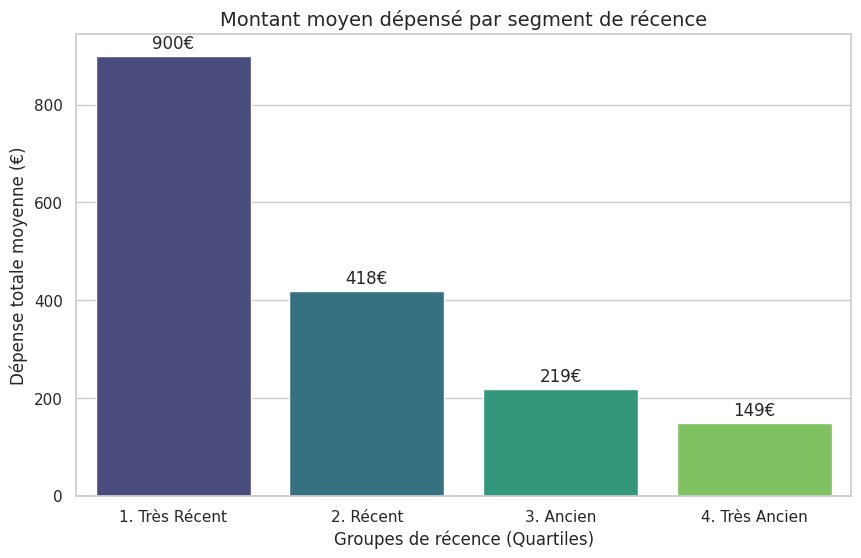

In [23]:
df['recency_group'] = pd.qcut(df['recency_days'], q=4, labels=['1. Très Récent', '2. Récent', '3. Ancien', '4. Très Ancien'])

plt.figure(figsize=(10, 6))
sns.barplot(x='recency_group', y='total_spent', data=df, palette='viridis', estimator='mean', errorbar=None)

ax = plt.gca()
for p in ax.patches:
    ax.annotate(f'{p.get_height():.0f}€', (p.get_x() + p.get_width() / 2., p.get_height()), ha='center', va='center', xytext=(0, 9), textcoords='offset points')

#graph
plt.title("Montant moyen dépensé par segment de récence", fontsize=14)
plt.xlabel("Groupes de récence (Quartiles)")
plt.ylabel("Dépense totale moyenne (€)")

plt.savefig('analyse_recence_lineaire.png')
print("Nouveau graphique généré : analyse_recence_lineaire.png")

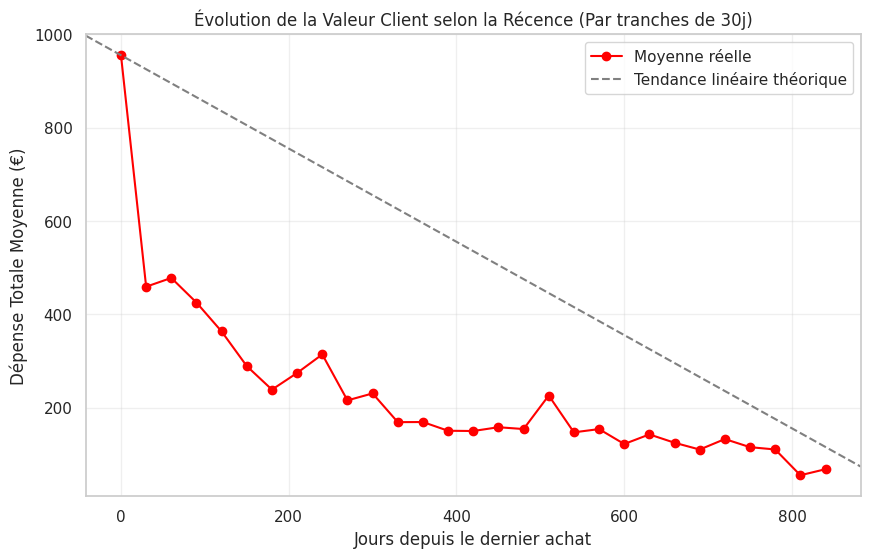

In [24]:
df['recency_bin'] = (df['recency_days'] // 30) * 30
trend = df.groupby('recency_bin')['total_spent'].mean().reset_index()

#graph
plt.figure(figsize=(10, 6))
plt.plot(trend['recency_bin'], trend['total_spent'], marker='o', linestyle='-', color='red', label='Moyenne réelle')
plt.axline((0, trend['total_spent'].iloc[0]), slope=-1, color='gray', linestyle='--', label='Tendance linéaire théorique')

plt.title("Évolution de la Valeur Client selon la Récence (Par tranches de 30j)")
plt.xlabel("Jours depuis le dernier achat")
plt.ylabel("Dépense Totale Moyenne (€)")
plt.legend()
plt.grid(True, alpha=0.3)

plt.savefig('tendance_non_lineaire.png')

Relation entre fréquence et panier moyen: les clients fréquents dépensent-ils plus par visite ?

Graphique généré avec succès !


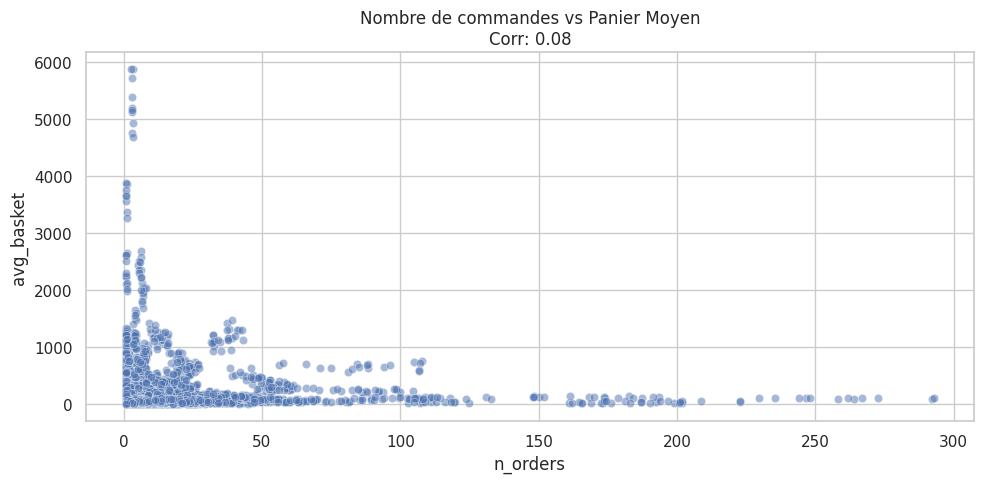

In [25]:
df["recency"] = (pd.to_datetime("2024-06-01") - pd.to_datetime(df["last_purchase"])).dt.days

fig, axes = plt.subplots(1, 1, figsize=(10, 5))
sns.scatterplot(x='n_orders', y='avg_basket', data=df, ax=axes, alpha=0.5)
axes.set_title(f"Nombre de commandes vs Panier Moyen\nCorr: {df['n_orders'].corr(df['avg_basket']):.2f}")

plt.tight_layout()
plt.savefig('analyse_marketing_finale.png')
print("Graphique généré avec succès !")

Y a-t-il des segments "naturellement visibles" dans les données avant toute modélisation ?

In [26]:
df.head()

,customer_id,country,first_purchase,last_purchase,n_orders,total_spent,avg_basket,recency_days,tenure_days,recency_group,recency_bin,recency
0,46995,United Kingdom,2011-08-09 12:20:00,2011-11-16 12:20:00,2.28,57.34,26.44,23.83,99.17,1. Très Récent,0.0,4580
1,22869,United Kingdom,2010-01-11 12:20:00,2011-10-30 12:20:00,46.53,19463.52,356.65,40.92,657.12,2. Récent,30.0,4597
2,12593,France,2011-05-05 09:29:00,2011-05-05 09:29:00,1.00,39.50,39.50,218.00,218.00,3. Ancien,210.0,4775
3,25889,United Kingdom,2008-07-14 12:20:00,2010-02-22 12:20:00,0.98,24.53,25.15,655.23,588.26,4. Très Ancien,630.0,5212
4,52931,United Kingdom,2009-08-29 12:20:00,2010-11-04 12:20:00,2.00,47.80,23.18,400.35,432.64,3. Ancien,390.0,4957


In [27]:
df.describe()

,customer_id,n_orders,total_spent,avg_basket,recency_days,tenure_days,recency_bin,recency
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000
mean,38390.294040,4.746364,421.538510,65.428104,238.454858,482.477138,224.239800,4795.073520
std,14517.833799,9.551931,2014.135812,139.874935,218.933454,224.947664,218.401026,218.928316
min,12346.000000,0.850000,0.160000,0.160000,0.000000,0.000000,0.000000,4557.000000
25%,25941.750000,1.060000,36.987500,21.787500,38.137500,343.822500,30.000000,4595.000000
50%,38441.500000,2.220000,99.640000,38.810000,168.000000,532.980000,150.000000,4725.000000
75%,50941.250000,5.210000,280.225000,69.100000,411.512500,662.260000,390.000000,4968.000000
max,63441.000000,292.780000,69630.660000,5876.150000,844.590000,848.620000,840.000000,5401.000000


Il y a des Prospects Actifs qu'il faut continuer de fidéliser. 
Ensuite on a des clients occasionnels qui passent de temps en temps mais il faut les chercher en faisant de l'activation passive (newsletter ou offre intéressante pour les faire revenir). 
Puis des clients fidèles qui se détache qu'il faut proposer des offres de réactivations.